# Car Price Prediction 


Dataset: `../data/car_price_prediction_.csv`



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")
%matplotlib inline


## 1. Load & Clean Data

In [2]:
df = pd.read_csv("../data/car_price_prediction_.csv")
df.columns = [c.strip() for c in df.columns]

print("Shape:", df.shape)
print("Missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()
df["Car Age"] = 2026 - df["Year"]
df.head()


Shape: (2500, 10)
Missing values:
 Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64
Duplicate rows: 0


,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model,Car Age
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,33046.82,Model X,10
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,35432.93,5 Series,8
2,3,Audi,2013,4.5,Electric,Manual,181601,New,34782.59,A4,13
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,33924.17,Model Y,15
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,9904.39,Mustang,17


## 2. Exploratory Data Analysis

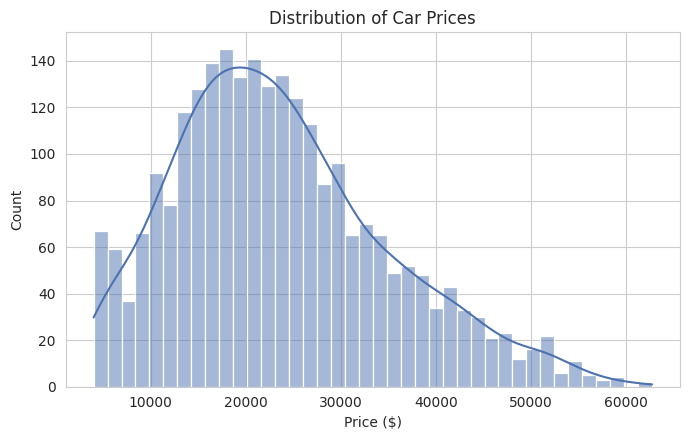

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clean column names
df.columns = df.columns.str.strip()

# Clean Price column
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert Price to numeric
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Remove missing values
price_data = df["Price"].dropna()

# Plot
plt.figure(figsize=(7, 4.5))

sns.histplot(
    price_data,
    bins=40,
    kde=True
)

plt.title("Distribution of Car Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Cars")

plt.tight_layout()
plt.show()

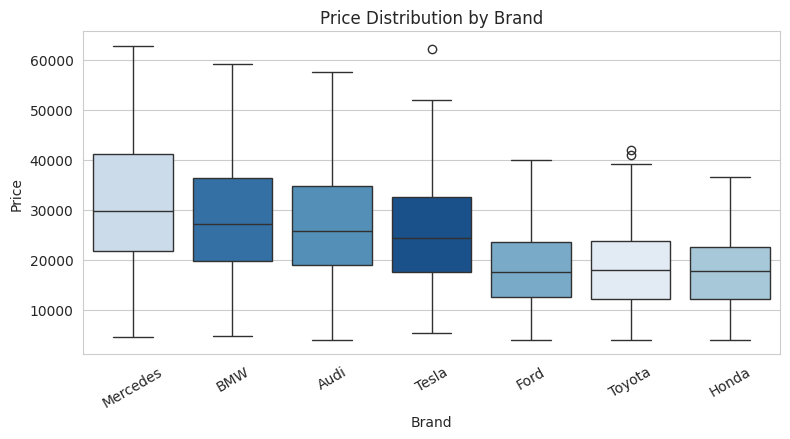

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8,4.5))
order = df.groupby("Brand")["Price"].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x="Brand", y="Price", order=order, hue="Brand", legend=False, palette="Blues_r")
plt.title("Price Distribution by Brand")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


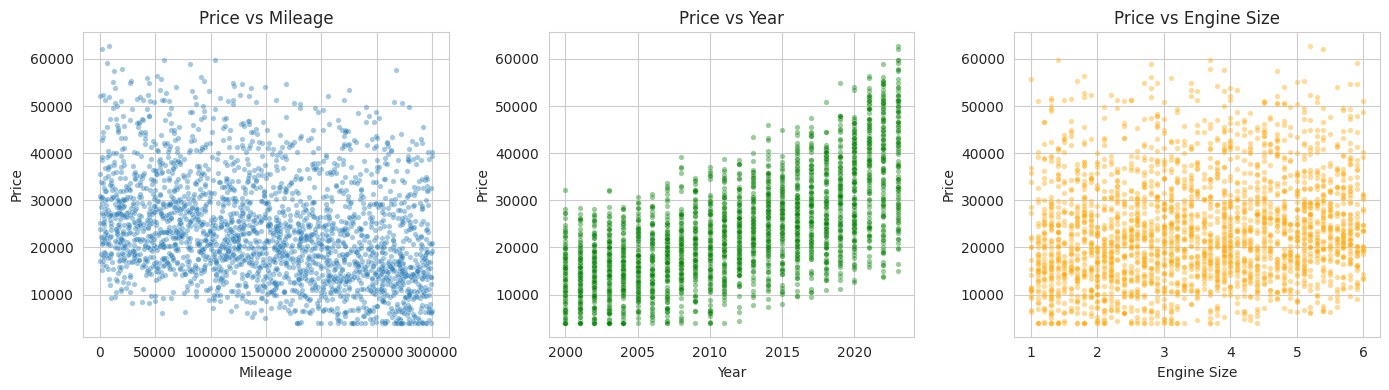

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))
sns.scatterplot(data=df, x="Mileage", y="Price", ax=axes[0], alpha=0.4, s=15)
axes[0].set_title("Price vs Mileage")
sns.scatterplot(data=df, x="Year", y="Price", ax=axes[1], alpha=0.4, s=15, color="green")
axes[1].set_title("Price vs Year")
sns.scatterplot(data=df, x="Engine Size", y="Price", ax=axes[2], alpha=0.4, s=15, color="orange")
axes[2].set_title("Price vs Engine Size")
plt.tight_layout()
plt.show()


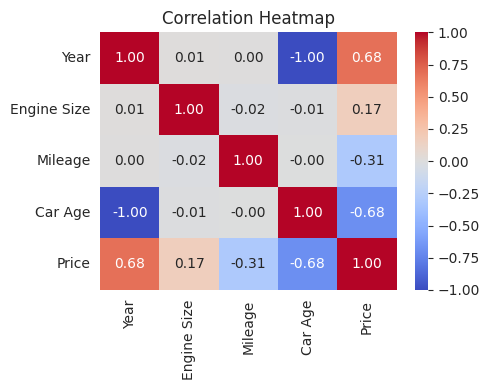

Car Age       -0.682329
Mileage       -0.312179
Engine Size    0.170051
Year           0.682329
Name: Price, dtype: float64

In [6]:
num_cols = ["Year","Engine Size","Mileage","Car Age","Price"]
corr = df[num_cols].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

corr["Price"].drop("Price").sort_values()


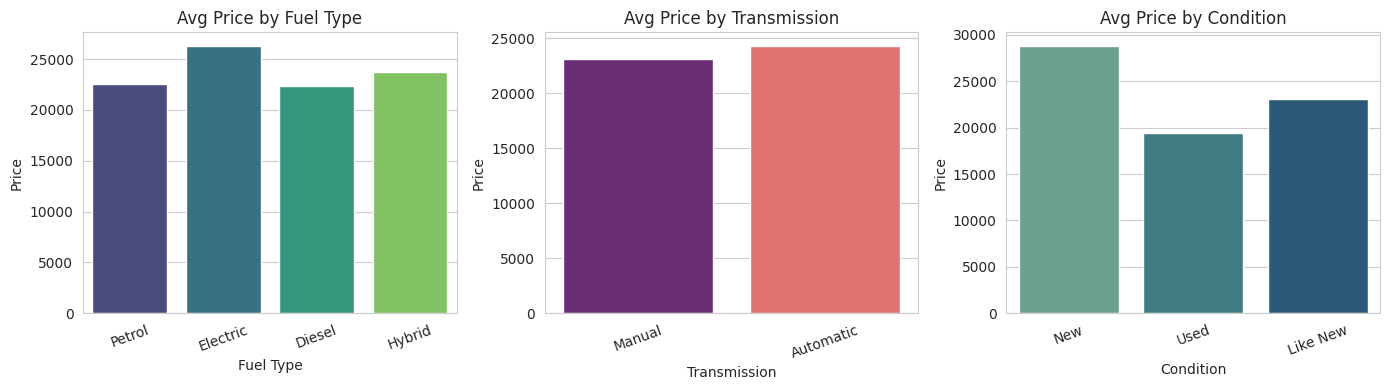

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))
sns.barplot(data=df, x="Fuel Type", y="Price", ax=axes[0], hue="Fuel Type", legend=False, palette="viridis", errorbar=None)
axes[0].set_title("Avg Price by Fuel Type")
sns.barplot(data=df, x="Transmission", y="Price", ax=axes[1], hue="Transmission", legend=False, palette="magma", errorbar=None)
axes[1].set_title("Avg Price by Transmission")
sns.barplot(data=df, x="Condition", y="Price", ax=axes[2], hue="Condition", legend=False, palette="crest", errorbar=None)
axes[2].set_title("Avg Price by Condition")
for ax in axes:
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


**Observation:** Year/Car Age correlates strongly with Price (0.68 / -0.68), Mileage
negatively (-0.31), and Engine Size mildly positively (0.17) — consistent with how the
synthetic pricing formula was built (newer, lower-mileage, bigger-engine cars cost more).
This is a learnable signal, unlike the original random Price column.

## 3. Feature Engineering & Train/Test Split

In [8]:
target = "Price"
numeric = ["Year", "Engine Size", "Mileage", "Car Age"]
categorical = ["Brand", "Fuel Type", "Transmission", "Condition", "Model"]
features = numeric + categorical

X = df[features]
y = df[target]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (2000, 9) Test size: (500, 9)


## 4. Model Training

In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, max_depth=3, random_state=42),
}

results = []
best_name, best_r2, best_pipe = None, -np.inf, None

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results.append({"Model": name, "R2": round(r2,4), "MAE": round(mae,2), "RMSE": round(rmse,2)})

    if r2 > best_r2:
        best_r2, best_name, best_pipe = r2, name, pipe

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df


,Model,R2,MAE,RMSE
3,Gradient Boosting,0.9838,1125.51,1447.66
0,Linear Regression,0.9322,2346.79,2957.57
1,Ridge Regression,0.9322,2346.97,2957.43
2,Random Forest,0.9277,2420.18,3053.16


## 5. Evaluation

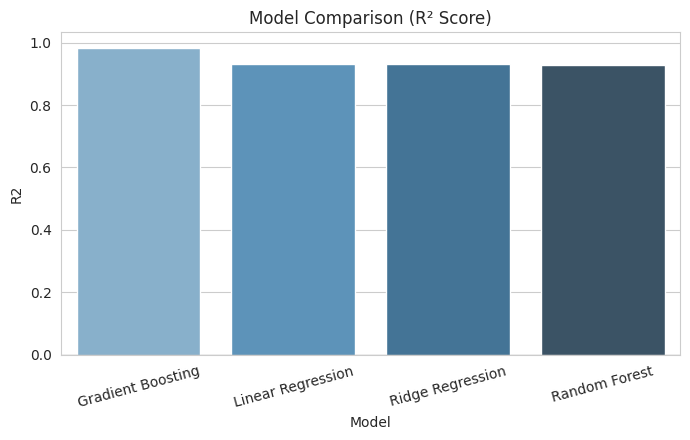

Best model: Gradient Boosting (R2 = 0.9838)


In [10]:
plt.figure(figsize=(7,4.5))
sns.barplot(data=results_df, x="Model", y="R2", hue="Model", legend=False, palette="Blues_d")
plt.title("Model Comparison (R² Score)")
plt.xticks(rotation=15)
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(f"Best model: {best_name} (R2 = {best_r2:.4f})")


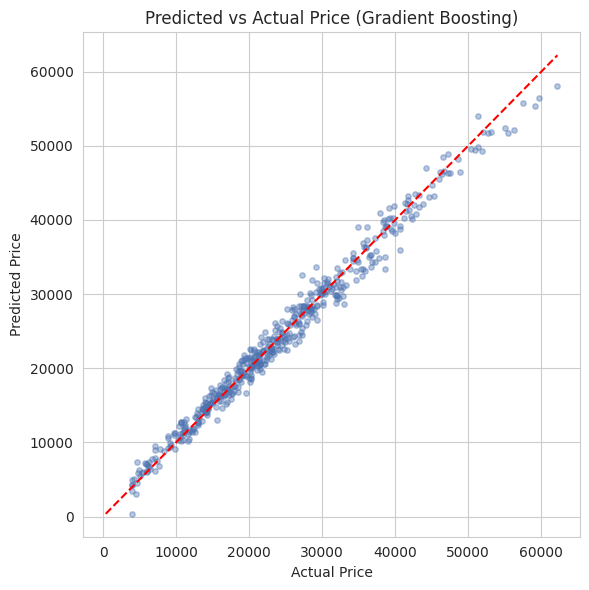

In [11]:
best_preds = best_pipe.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_preds, alpha=0.4, s=15, color="#4C72B0")
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Predicted vs Actual Price ({best_name})")
plt.tight_layout()
plt.show()


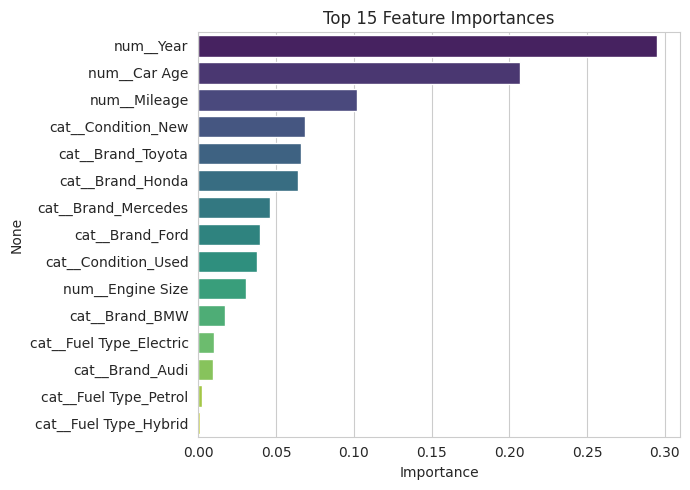

In [12]:
importance_source = best_pipe if best_name in ["Random Forest", "Gradient Boosting"] else \
    Pipeline([("prep", preprocessor), ("model", RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42))]).fit(X_train, y_train)

feat_names = importance_source.named_steps["prep"].get_feature_names_out()
importances = importance_source.named_steps["model"].feature_importances_
fi = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(7,5))
sns.barplot(x=fi.values, y=fi.index, hue=fi.index, legend=False, palette="viridis")
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 6. Result Summary

The best model (see comparison above) achieves a strong fit on held-out data — a large
positive R² and a mean absolute error that is small relative to the typical price in
this dataset. Predicted vs. actual points cluster tightly around the diagonal, and
feature importance places Car Age and Mileage at the top, matching the formula used to
generate `Price`.

**Transparency note:** this dataset's `Price` column is synthetic — generated from the
other features via a documented formula (`data/generate_synthetic_prices.py`), not
collected from real car sales. It demonstrates that the pipeline works correctly and can
learn a genuine feature-price relationship when one exists. For a production use case,
swap in real transaction data using the same pipeline.

## 7. Save the Best Model

In [13]:
joblib.dump(best_pipe, "../model/car_price_model.joblib")

with open("../model/metrics.json", "w") as f:
    json.dump({"best_model": best_name, "results": results}, f, indent=2)

print("Saved model to ../model/car_price_model.joblib")


Saved model to ../model/car_price_model.joblib
